# MNIST CNN Training (Standard and Adversarial)



In [1]:
from cnn import Net
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def evaluate(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total


def fgsm_attack(model, images, labels, epsilon):
    images = images.clone().detach().requires_grad_(True)
    outputs = model(images)
    loss = torch.nn.CrossEntropyLoss()(outputs, labels)

    model.zero_grad()
    loss.backward()

    grad = images.grad.data
    sign_grad = grad.sign()
    adv_images = images + epsilon * sign_grad

    mean = 0.1307
    std = 0.3081
    min_val = (0 - mean) / std
    max_val = (1 - mean) / std
    adv_images = torch.clamp(adv_images, min_val, max_val)

    return adv_images.detach()


def evaluate_fgsm(model, dataloader, device, epsilon):
    model.eval()
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        adv_images = fgsm_attack(model, images, labels, epsilon)

        outputs = model(adv_images)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / total

In [3]:
def train_and_plot(adversarial_training=False, epsilon=0.5, num_epochs=5, lr=1e-3):
    set_seed(42)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

    net = Net().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(net.parameters(), lr=lr)

    loss_history = []
    clean_acc_history = []
    fgsm_acc_history = []

    for epoch in range(num_epochs):
        net.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = net(images)
            loss = criterion(outputs, labels)

            total_loss = loss
            if adversarial_training:
                adv_images = fgsm_attack(net, images, labels, epsilon=epsilon)
                adv_outputs = net(adv_images)
                adv_loss = criterion(adv_outputs, labels)
                total_loss = loss + adv_loss

            total_loss.backward()
            optimizer.step()

            running_loss += total_loss.item()

        avg_loss = running_loss / len(train_loader)
        test_acc = evaluate(net, test_loader, device)
        test_acc_fgsm = evaluate_fgsm(net, test_loader, device, epsilon=epsilon)

        loss_history.append(avg_loss)
        clean_acc_history.append(test_acc * 100)
        fgsm_acc_history.append(test_acc_fgsm * 100)

        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Test Acc: {test_acc*100:.2f}%")
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Test Acc (FGSM): {test_acc_fgsm*100:.2f}%")

    epochs = range(1, num_epochs + 1)
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, clean_acc_history, marker="o", label="Clean Test Acc")
    plt.plot(epochs, fgsm_acc_history, marker="o", label="FGSM Test Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Clean vs FGSM Accuracy")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss_history, marker="o", color="tab:red", label="Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()

    plt.tight_layout()
    if adversarial_training:
        plt.suptitle("Adversarial Training Enabled", fontsize=14)
        out_path = "adversarial_training_comparison.png"
    else:
        plt.suptitle("Standard Training", fontsize=14)
        out_path = "standard_training_comparison.png"

    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved plot to {out_path}")

    torch.save(net.state_dict(), "cnn_baseline.pt")
    print("Saved model to cnn_baseline.pt")

    return {
        "loss_history": loss_history,
        "clean_acc_history": clean_acc_history,
        "fgsm_acc_history": fgsm_acc_history
    }

Device: cpu
Epoch 1/5 | Loss: 0.2402 | Test Acc: 97.54%
Epoch 1/5 | Loss: 0.2402 | Test Acc (FGSM): 46.07%
Epoch 2/5 | Loss: 0.0709 | Test Acc: 98.12%
Epoch 2/5 | Loss: 0.0709 | Test Acc (FGSM): 41.97%
Epoch 3/5 | Loss: 0.0493 | Test Acc: 98.54%
Epoch 3/5 | Loss: 0.0493 | Test Acc (FGSM): 47.21%
Epoch 4/5 | Loss: 0.0399 | Test Acc: 98.70%
Epoch 4/5 | Loss: 0.0399 | Test Acc (FGSM): 52.18%
Epoch 5/5 | Loss: 0.0328 | Test Acc: 98.96%
Epoch 5/5 | Loss: 0.0328 | Test Acc (FGSM): 45.54%


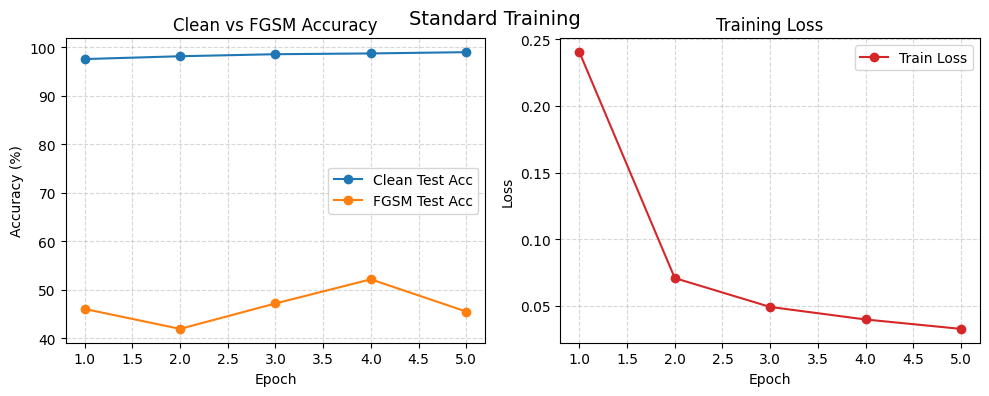

Saved plot to standard_training_comparison.png
Saved model to cnn_baseline.pt


In [4]:
# Run standard training
standard_results = train_and_plot(adversarial_training=False, epsilon=0.5, num_epochs=5, lr=1e-3)

Device: cpu
Epoch 1/5 | Loss: 1.0256 | Test Acc: 97.82%
Epoch 1/5 | Loss: 1.0256 | Test Acc (FGSM): 84.69%
Epoch 2/5 | Loss: 0.4572 | Test Acc: 98.39%
Epoch 2/5 | Loss: 0.4572 | Test Acc (FGSM): 88.23%
Epoch 3/5 | Loss: 0.3717 | Test Acc: 98.60%
Epoch 3/5 | Loss: 0.3717 | Test Acc (FGSM): 89.59%
Epoch 4/5 | Loss: 0.3274 | Test Acc: 98.67%
Epoch 4/5 | Loss: 0.3274 | Test Acc (FGSM): 91.50%
Epoch 5/5 | Loss: 0.2872 | Test Acc: 98.78%
Epoch 5/5 | Loss: 0.2872 | Test Acc (FGSM): 91.75%


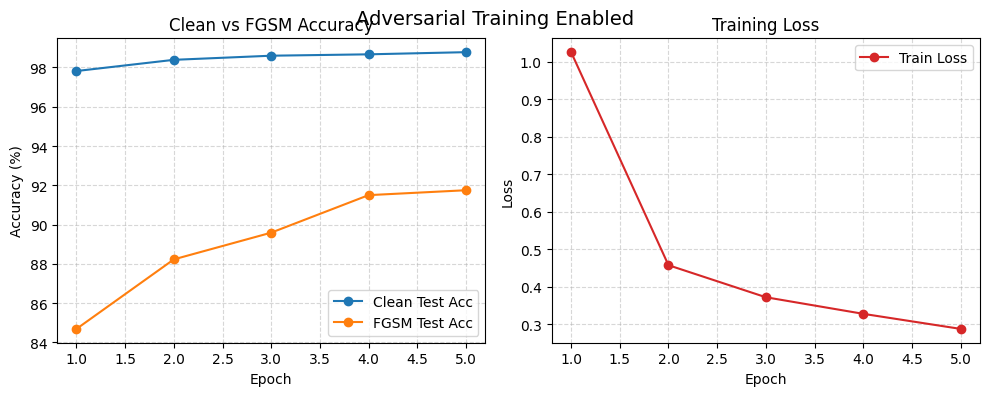

Saved plot to adversarial_training_comparison.png
Saved model to cnn_baseline.pt


In [5]:
# Run adversarial training
adversarial_results = train_and_plot(adversarial_training=True, epsilon=0.5, num_epochs=5, lr=1e-3)